In [ ]:
import numpy as np
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix

In [ ]:
dataset = load_breast_cancer()

X = dataset.data
y = dataset.target

print("Dataset Shape :", X.shape)
print("Target Shape  :", y.shape)

Dataset Shape : (569, 30)
Target Shape  : (569,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(30,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.4588 - loss: 0.7590 - val_accuracy: 0.8462 - val_loss: 0.5210
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9368 - loss: 0.4110 - val_accuracy: 0.9341 - val_loss: 0.3130
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9478 - loss: 0.2620 - val_accuracy: 0.9341 - val_loss: 0.2211
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9478 - loss: 0.1867 - val_accuracy: 0.9341 - val_loss: 0.1741
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9533 - loss: 0.1433 - val_accuracy: 0.9341 - val_loss: 0.1466
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9670 - loss: 0.1164 - val_accuracy: 0.9451 - val_loss: 0.1307
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9753 - loss: 0.0977 - val_accuracy: 0.9451 - val_loss: 0.1203
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9808 - loss: 0.0856 - val_accuracy: 0.9670 - v

In [ ]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step



========== Evaluation ==========
Accuracy : 0.9824561403508771
Precision: 0.9726027397260274
Recall   : 1.0
F1 Score : 0.9861111111111112

Confusion Matrix
[[41  2]
 [ 0 71]]


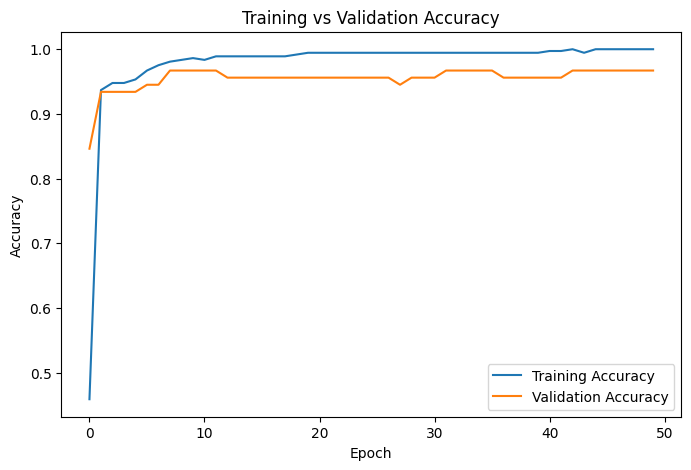

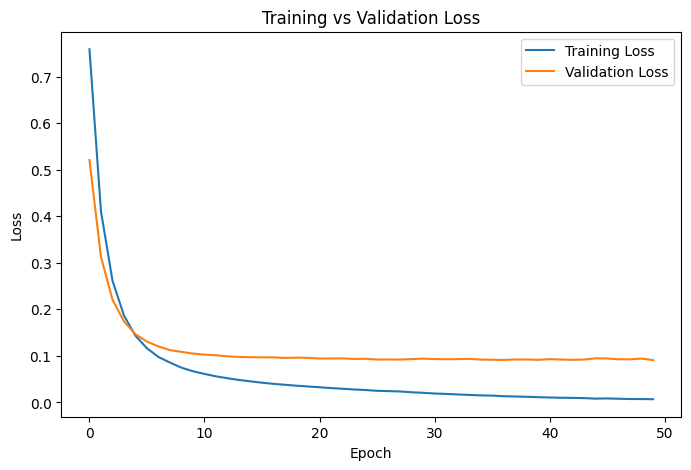

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n========== Evaluation ==========")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix")
print(cm)

# Accuracy Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()